In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# Check what's actually in your Drive first, if you're not sure of the exact path
!ls "/content/drive/MyDrive/" | grep -i apple

appledataset.zip


In [4]:
!cp "/content/drive/MyDrive/appledataset.zip" /content/apple_dataset.zip
!unzip -q /content/apple_dataset.zip -d /content/apple_dataset

In [5]:
!find /content/apple_dataset -maxdepth 4 | head -40

/content/apple_dataset
/content/apple_dataset/test
/content/apple_dataset/test/_MG_8071_21.jpg
/content/apple_dataset/test/_MG_8071_11.jpg
/content/apple_dataset/test/_MG_9000_05.jpg
/content/apple_dataset/test/_MG_8915_12.jpg
/content/apple_dataset/test/_MG_8903_21.jpg
/content/apple_dataset/test/_MG_8993_04.jpg
/content/apple_dataset/test/_MG_3004_01.jpg
/content/apple_dataset/test/_MG_8971_13.jpg
/content/apple_dataset/test/_MG_7954_04.jpg
/content/apple_dataset/test/_MG_8080_15.jpg
/content/apple_dataset/test/_MG_3168_13.jpg
/content/apple_dataset/test/_MG_7954_19.jpg
/content/apple_dataset/test/_MG_8065_15.jpg
/content/apple_dataset/test/_MG_3168_08.jpg
/content/apple_dataset/test/_MG_3017_17.jpg
/content/apple_dataset/test/_MG_7954_09.jpg
/content/apple_dataset/test/_MG_3168_03.jpg
/content/apple_dataset/test/_MG_3004_21.jpg
/content/apple_dataset/test/_MG_8065_05.jpg
/content/apple_dataset/test/_MG_8903_01.jpg
/content/apple_dataset/test/_MG_3168_18.jpg
/content/apple_dataset/te

In [6]:
!cat /content/apple_dataset/data.yaml

cat: /content/apple_dataset/data.yaml: No such file or directory


In [7]:
import os

BASE = '/content/apple_dataset'

print("--- Folder structure ---")
for root, dirs, files in os.walk(BASE):
    depth = root.replace(BASE, '').count(os.sep)
    if depth > 2:
        continue
    indent = '  ' * depth
    print(f"{indent}{os.path.basename(root)}/")
    if depth == 2:
        sample_files = files[:3]
        for f in sample_files:
            print(f"{indent}  {f}")

--- Folder structure ---
apple_dataset/
  test/
    .ipynb_checkpoints/
      _MG_3004_11-checkpoint.jpg
      _MG_3004_01-checkpoint.jpg
      _MG_3004_06-checkpoint.jpg
  train/
    yolo_labels/
      _MG_8993_02.txt
      _MG_8993_11.txt
      _MG_8971_12.txt
    .ipynb_checkpoints/
      _MG_3004_02-checkpoint.jpg


In [8]:
train_files = os.listdir("/content/apple_dataset/train")
print(train_files[:20])
print(f"\n total items in train /: {len(train_files)}")

['_MG_7954_07.jpg', '_MG_8080_12.jpg', '_MG_8903_05.jpg', '_MG_8915_15.jpg', '_MG_8915_21.jpg', '_MG_3004_04.jpg', '_MG_8971_19.jpg', '_MG_8993_05.jpg', '_MG_8915_08.jpg', '_MG_8993_10.jpg', '_MG_8993_23.jpg', '_MG_8993_08.jpg', '_MG_8903_23.jpg', '_MG_8080_11.jpg', '_MG_9000_07.jpg', '_MG_8915_23.jpg', '_MG_3004_24.jpg', '_MG_8915_13.jpg', '_MG_8993_03.jpg', '_MG_7954_17.jpg']

 total items in train /: 233


In [9]:
import os
import shutil
import random

BASE = '/content/apple_dataset'
SRC_IMAGES = f'{BASE}/train'
SRC_LABELS = f'{BASE}/train/yolo_labels'
DATASET_DIR = f'{BASE}/dataset'

for split in ['train', 'val']:
    os.makedirs(f'{DATASET_DIR}/images/{split}', exist_ok=True)
    os.makedirs(f'{DATASET_DIR}/labels/{split}', exist_ok=True)

image_files = sorted([f for f in os.listdir(SRC_IMAGES)
                       if f.lower().endswith(('.jpg', '.jpeg', '.png'))
                       and os.path.isfile(os.path.join(SRC_IMAGES, f))])

print(f"Total valid images found: {len(image_files)}")

random.seed(42)
random.shuffle(image_files)

split_idx = int(len(image_files) * 0.8)
train_files = image_files[:split_idx]
val_files = image_files[split_idx:]

def place_files(files, split):
    for img_name in files:
        base_name = os.path.splitext(img_name)[0]
        label_name = base_name + '.txt'

        shutil.copy(os.path.join(SRC_IMAGES, img_name),
                    f'{DATASET_DIR}/images/{split}/{img_name}')

        src_label = os.path.join(SRC_LABELS, label_name)
        if os.path.exists(src_label):
            shutil.copy(src_label, f'{DATASET_DIR}/labels/{split}/{label_name}')
        else:
            open(f'{DATASET_DIR}/labels/{split}/{label_name}', 'w').close()

place_files(train_files, 'train')
place_files(val_files, 'val')

print(f"Train: {len(train_files)} images | Val: {len(val_files)} images")

Total valid images found: 231
Train: 184 images | Val: 47 images


In [10]:
import yaml
yaml_content = {
    'path': f'{BASE}/dataset',
    'train': 'images/train',
    'val': 'images/val',
    'names': {0:'apple'}
}
with open(f'{BASE}/dataset/data.yaml','w') as f:
  yaml.dump(yaml_content, f)

print("data.yaml created")
!cat {BASE}/dataset/data.yaml

data.yaml created
names:
  0: apple
path: /content/apple_dataset/dataset
train: images/train
val: images/val


In [11]:
print("Train images:", len(os.listdir(f'{DATASET_DIR}/images/train')))
print("Train labels:", len(os.listdir(f'{DATASET_DIR}/labels/train')))
print("Val images:", len(os.listdir(f'{DATASET_DIR}/images/val')))
print("Val labels:", len(os.listdir(f'{DATASET_DIR}/labels/val')))

Train images: 184
Train labels: 184
Val images: 47
Val labels: 47


In [12]:
! pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 69.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.2/66.2 kB 7.8 MB/s eta 0:00:00


In [14]:
from ultralytics import YOLO

model = YOLO('yolov8n.pt')

results = model.train(
    data='/content/apple_dataset/dataset/data.yaml',
    epochs=150,
    imgsz=320,
    batch=16,
    patience=20,
    device=0,
    project='apple_counter',
    name='yolov8n_apple_merged_v3',
)

Ultralytics 8.4.136 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/apple_dataset/dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=150, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=320, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8n_apple_merged

In [15]:
metric = model.val()
print("map@5.0", metric.box.map50)
print("mAP@0.5:0.95",metric.box.map)

Ultralytics 8.4.136 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3516.5±841.2 MB/s, size: 168.8 KB)
val: Scanning /content/apple_dataset/dataset/labels/val.cache... 47 images, 10 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 47/47 15.2Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 3/3 1.3it/s 2.3s
                   all         47        445      0.848      0.778      0.833      0.601
Speed: 1.7ms preprocess, 16.7ms inference, 0.0ms loss, 5.8ms postprocess per image
Results saved to /content/runs/detect/val
map@5.0 0.8325007694752782
mAP@0.5:0.95 0.6012399938202101


In [30]:
import matplotlib.pyplot as plt
import cv2
def predict(path,conf=0.1,iou=0.3):
  results = model(path, conf=conf, iou=iou)
  r=results[0]
  annoted = r.plot()
  plt.figure(figsize=(10,10))
  plt.imshow(cv2.cvtColor(annoted, cv2.COLOR_BGR2RGB))
  plt.axis('off')
  plt.title(f"Detected: {len(r.boxes)} apples")
  plt.show()


image 1/1 /content/apple_dataset/test/_MG_7954_09.jpg: 320x320 19 apples, 12.6ms
Speed: 2.6ms preprocess, 12.6ms inference, 2.2ms postprocess per image at shape (1, 3, 320, 320)


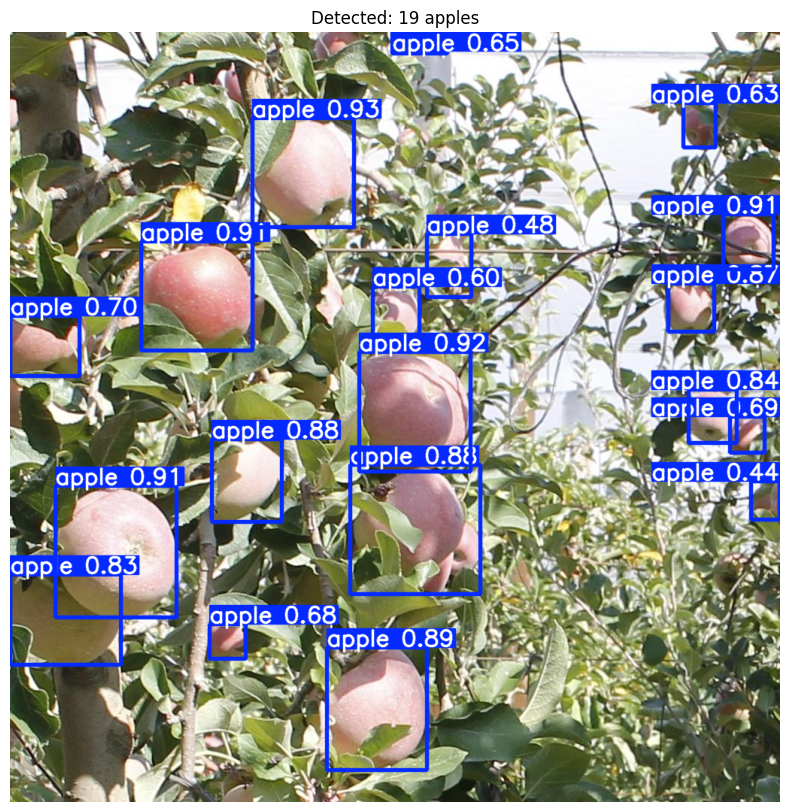

In [39]:
predict('/content/apple_dataset/test/_MG_7954_09.jpg',conf=0.4)


image 1/1 /content/apple_dataset/test/_MG_8915_07.jpg: 320x320 (no detections), 8.6ms
Speed: 1.5ms preprocess, 8.6ms inference, 0.9ms postprocess per image at shape (1, 3, 320, 320)


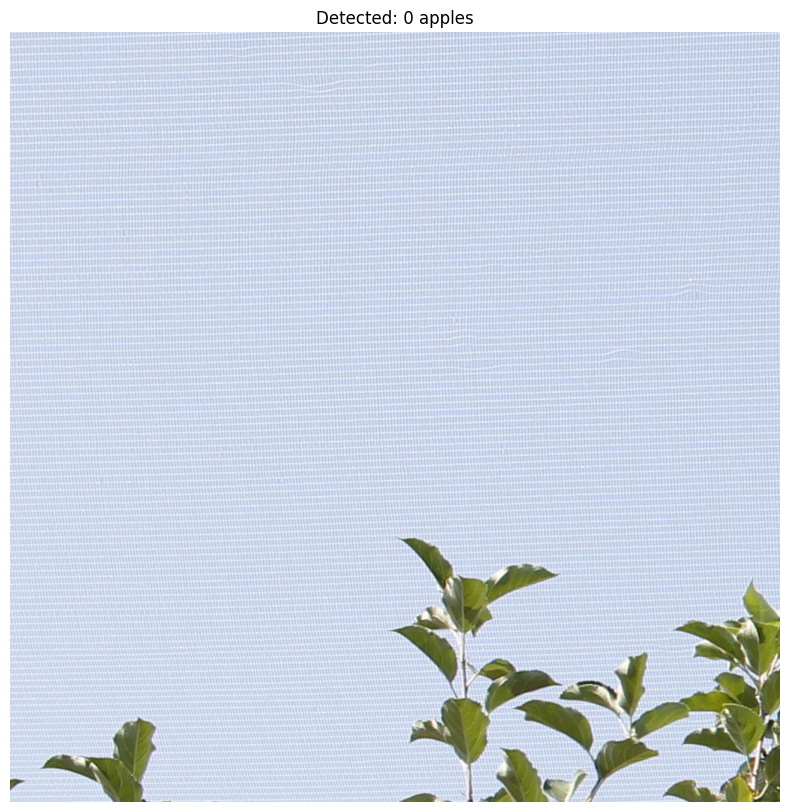

In [32]:
predict('/content/apple_dataset/test/_MG_8915_07.jpg')


image 1/1 /content/apple_dataset/test/_MG_8993_14.jpg: 320x320 16 apples, 6.9ms
Speed: 1.3ms preprocess, 6.9ms inference, 1.4ms postprocess per image at shape (1, 3, 320, 320)


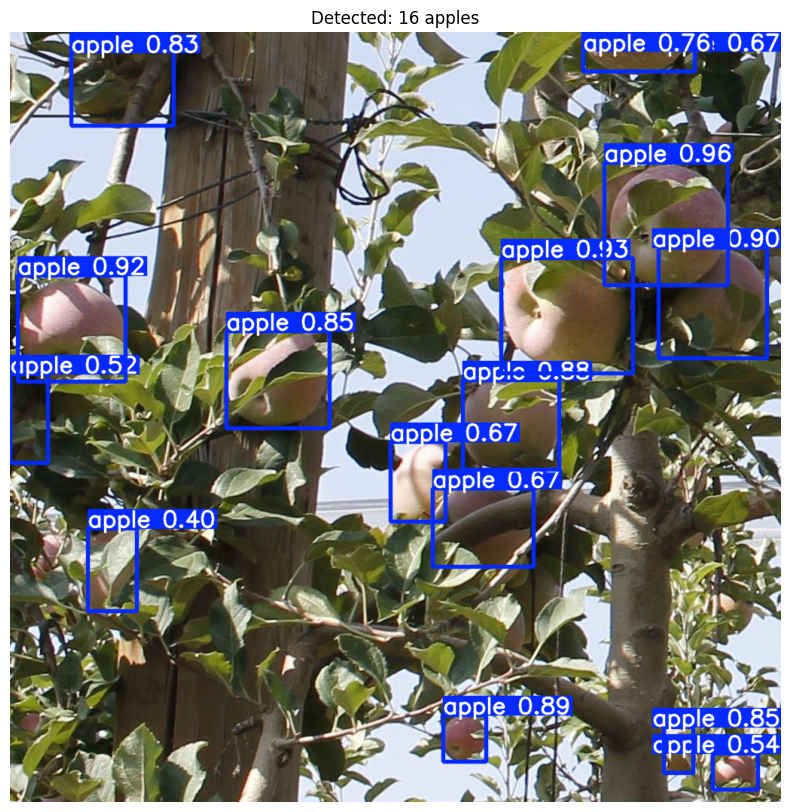

In [42]:
predict('/content/apple_dataset/test/_MG_8993_14.jpg',conf=0.4)


image 1/1 /content/apple_dataset/test/_MG_8993_14.jpg: 320x320 19 apples, 7.0ms
Speed: 1.3ms preprocess, 7.0ms inference, 1.6ms postprocess per image at shape (1, 3, 320, 320)


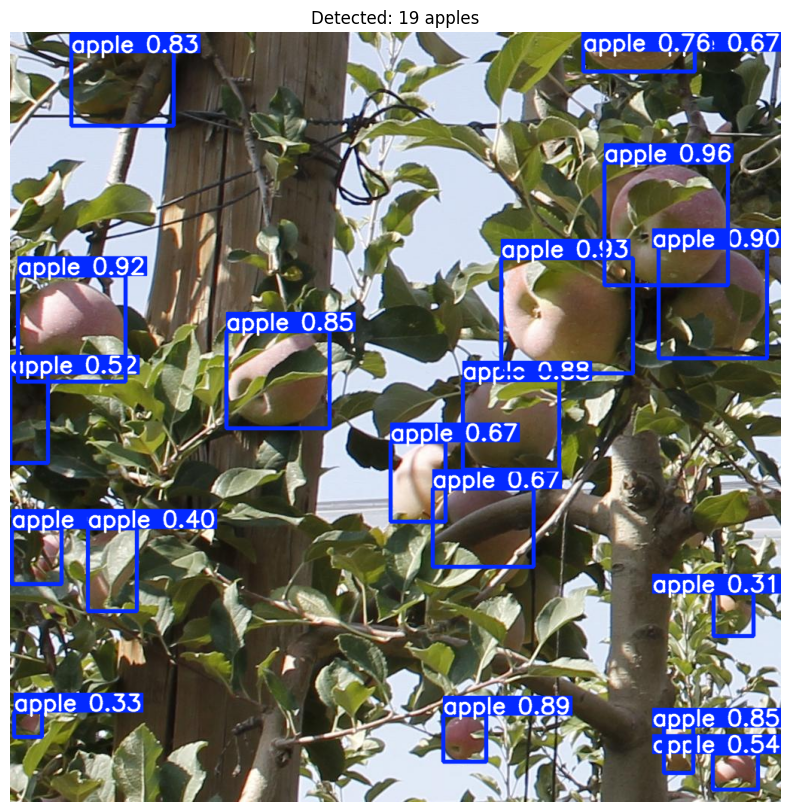

In [43]:
predict('/content/apple_dataset/test/_MG_8993_14.jpg',conf=0.3)

In [44]:
from google.colab import files
files.download('/content/runs/detect/apple_counter/yolov8n_apple_merged_v3-2/weights/best.pt')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>